### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

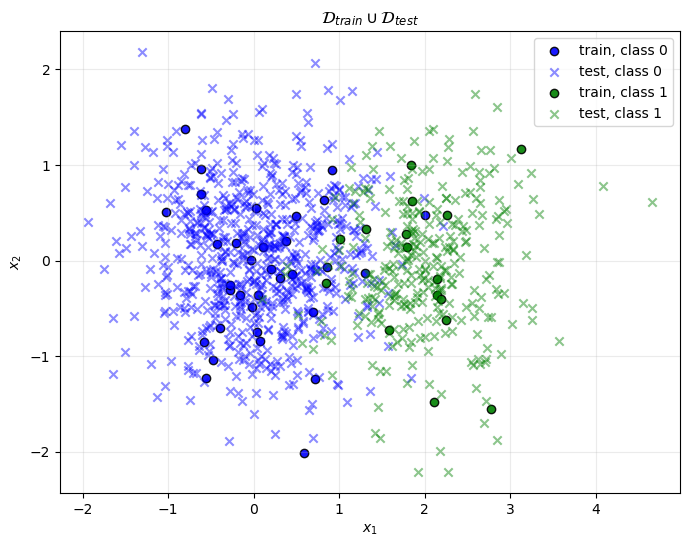

In [1]:
import numpy as np
import matplotlib.pyplot as plt

EPSILON = 2
P = 0.30

def dataset(N, epsilon=EPSILON, p=P):

    U = np.random.rand(N)
    y = (U<p).astype(int)

    mu0 = np.array([0,0])
    mu1 = np.array([epsilon, 0])
    sigma0 = np.array([[0.5, 0], [0, 0.5]])
    sigma1 = np.array([[0.4, 0], [0, 0.4]])

    cls0 = y == 0
    cls1 = y == 1

    X = np.empty((N, 2))

    X[cls0] = np.random.multivariate_normal(mu0, sigma0, size=cls0.sum())
    X[cls1] = np.random.multivariate_normal(mu1, sigma1, size=cls1.sum())

    return X, y


X_train, y_train = dataset(50)
X_test, y_test = dataset(1000)


fig, ax = plt.subplots(figsize=(8,6))
colors = ['blue', 'green']

for cls in range(2):

    train_mask = y_train == cls

    ax.scatter(
        X_train[train_mask, 0],
        X_train[train_mask, 1],
        marker='o',
        c=colors[cls],
        edgecolors="black",
        label=f"train, class {cls}",
        alpha=0.9
    )

    test_mask = y_test == cls
    ax.scatter(
        X_test[test_mask, 0],
        X_test[test_mask, 1],
        marker="x",
        c=colors[cls],
        label=f"test, class {cls}",
        alpha=0.45
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax.set_title(r"$\mathcal{D}_{train} \cup \mathcal{D}_{test}$")

ax.legend()
ax.grid(alpha=0.25)

plt.show()


**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The Bayes classifier chooses the class which has the largest posterior probability for a given point $\mathbf{x} = (x_1, x_2)^\top$. In our case, this means that we predict class 1 if

$$
\frac{\mathbb{P}(Y=1 \mid \mathbf{x})}{\mathbb{P}(Y=0 \mid \mathbf{x})} > 1.
$$

Using Bayes' formula, this ratio becomes

$$
\frac{\mathbb{P}(Y=1 \mid \mathbf{x})}{\mathbb{P}(Y=0 \mid \mathbf{x})}
= \frac{p f_1(\mathbf{x})}{(1-p) f_0(\mathbf{x})},
$$

where $f_0$ and $f_1$ are the densities of the two Gaussian distributions. Therefore the classifier is

$$
\widehat{g}_{Bayes}(\mathbf{x}) =
\begin{cases}
1, & \text{if } p f_1(\mathbf{x}) > (1-p) f_0(\mathbf{x}), \\
0, & \text{otherwise.}
\end{cases}
$$

The decision boundary corresponds to the points where the two weighted densities are equal. Taking the logarithm gives the equation

$$
\log\left(\frac{p}{1-p}\right)
+ \frac{1}{2}\log\left(\frac{\det(\Sigma_0)}{\det(\Sigma_1)}\right)
- \frac{1}{2}\left[
(\mathbf{x}-\mu_1)^\top\Sigma_1^{-1}(\mathbf{x}-\mu_1)
-(\mathbf{x}-\mu_0)^\top\Sigma_0^{-1}(\mathbf{x}-\mu_0)
\right] = 0.
$$

For the values of the exercise, $p=0.30$, $\varepsilon=2$, $\mu_0=(0,0)^\top$, $\mu_1=(2,0)^\top$, $\Sigma_0=0.5I_2$ and $\Sigma_1=0.4I_2$. So the boundary can be written as

$$
\log\left(\frac{0.3}{0.7}\right)
+ \frac{1}{2}\log\left(\frac{0.5^2}{0.4^2}\right)
- \frac{1}{2}\left[
2.5\big((x_1-2)^2+x_2^2\big)
-2\big(x_1^2+x_2^2\big)
\right] = 0.
$$

Because the two covariance matrices are different, the boundary is not a straight line. It is a quadratic boundary.

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

Estimated Bayes error for epsilon=2: 0.0671


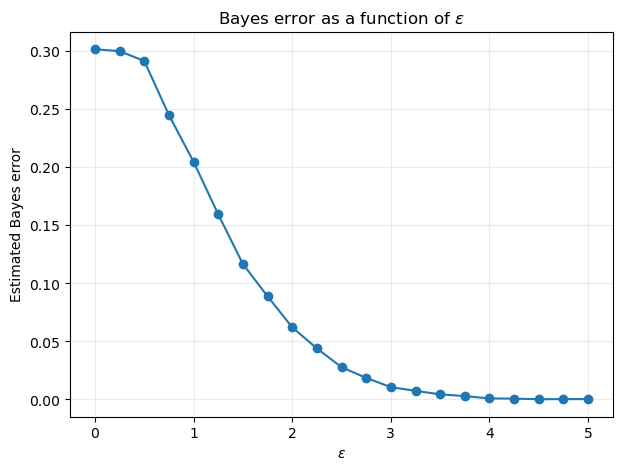

When epsilon increases, the two classes become more separated, so the Bayes error decreases.


In [2]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import zero_one_loss
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import validate_data, check_is_fitted


class BayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epsilon=2, p=0.30):
        self.epsilon = epsilon
        self.p = p

    def fit(self, X, y):

        # Check that X and y have correct shape, set n_features_in_, etc.
        X, y = validate_data(self, X, y)
        # Store the classes seen during fit
        self.classes_ = unique_labels(y)

        self.X_ = X
        self.y_ = y
        self.mu0_ = np.array([0, 0])
        self.mu1_ = np.array([self.epsilon, 0])
        self.sigma0_ = np.array([[0.5, 0], [0, 0.5]])
        self.sigma1_ = np.array([[0.4, 0], [0, 0.4]])
        self.inv_sigma0_ = np.linalg.inv(self.sigma0_)
        self.inv_sigma1_ = np.linalg.inv(self.sigma1_)
        self.det_sigma0_ = np.linalg.det(self.sigma0_)
        self.det_sigma1_ = np.linalg.det(self.sigma1_)

        return self

    def predict(self, X):

        # Check if fit has been called
        check_is_fitted(self)

        # Input validation
        X = validate_data(self, X, reset=False)


        X = np.asarray(X)
        diff0 = X - self.mu0_
        diff1 = X - self.mu1_

        q0 = np.sum((diff0 @ self.inv_sigma0_) * diff0, axis=1)
        q1 = np.sum((diff1 @ self.inv_sigma1_) * diff1, axis=1)

        log_ratio = (
            np.log(self.p / (1 - self.p))
            + 0.5 * np.log(self.det_sigma0_ / self.det_sigma1_)
            - 0.5 * (q1 - q0)
        )
        return (log_ratio > 0).astype(int)


# Bayes error for D(10^4 | 2, 0.3)
X_bayes, y_bayes = dataset(10**4)
bayes_estimator = BayesClassifier().fit(X_bayes, y_bayes)
y_pred = bayes_estimator.predict(X_bayes)
bayes_error = zero_one_loss(y_bayes, y_pred)

print(f"Estimated Bayes error for epsilon=2: {bayes_error:.4f}")


# Evolution of the Bayes error when epsilon changes
epsilons = np.linspace(0, 5, 21)
errors = []

for eps in epsilons:
    X_eps, y_eps = dataset(10**4, epsilon=eps)
    estimator = BayesClassifier(epsilon=eps).fit(X_eps, y_eps)
    y_pred_eps = estimator.predict(X_eps)
    errors.append(zero_one_loss(y_eps, y_pred_eps))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epsilons, errors, marker="o")
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel("Estimated Bayes error")
ax.set_title(r"Bayes error as a function of $\varepsilon$")
ax.grid(alpha=0.25)
plt.show()

print("When epsilon increases, the two classes become more separated, so the Bayes error decreases.")

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

The optimal classifier in this setting is the Bayes classifier, since we know the class priors and the conditional pdfs used to generate the data.

Among the methods seen in class, QDA seems the most appropriate. The reason is that the observations are generated from Gaussian distributions in each class, so this fits the framework of Gaussian discriminant analysis:

$$
X \mid Y=0 \sim \mathcal{N}(\mu_0, \Sigma_0), \qquad
X \mid Y=1 \sim \mathcal{N}(\mu_1, \Sigma_1).
$$

However, the two covariance matrices are not equal:

$$
\Sigma_0 = 0.5 I_2 \qquad \text{and} \qquad \Sigma_1 = 0.4 I_2.
$$

Therefore, the shared covariance assumption of LDA is not satisfied. QDA is more suitable because it allows different covariance matrices for the two classes, which leads to a quadratic decision boundary. Logistic regression is less adapted here because it is a linear classifier, while the true boundary is not linear.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

Bayes test error: 0.0600


,classifier,train_error,test_error,gap_to_bayes
0,LDA,0.08,0.066,0.006
1,QDA,0.08,0.062,0.002
2,Logistic regression,0.08,0.057,-0.003


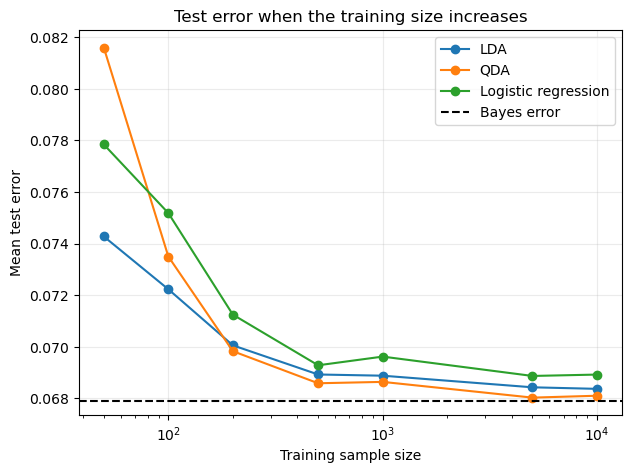

,n_train,classifier,test_error,gap_to_bayes
0,50,LDA,0.074277,0.006377
1,50,Logistic regression,0.077843,0.009943
2,50,QDA,0.081597,0.013697
3,100,LDA,0.072230,0.004330
4,100,Logistic regression,0.075183,0.007283
5,100,QDA,0.073500,0.005600
6,200,LDA,0.070057,0.002157
7,200,Logistic regression,0.071247,0.003347
8,200,QDA,0.069830,0.001930
9,500,LDA,0.068927,0.001027


In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
import pandas as pd


def make_classifiers():
    return {
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(reg_param=1e-6),
        "Logistic regression": LogisticRegression(max_iter=1000),
    }

# Bayes error on the same test set, used as a reference
bayes_reference = BayesClassifier().fit(X_train, y_train)
bayes_test_error = zero_one_loss(y_test, bayes_reference.predict(X_test))

results = []

for name, clf in make_classifiers().items():
    clf.fit(X_train, y_train)
    train_error = zero_one_loss(y_train, clf.predict(X_train))
    test_error = zero_one_loss(y_test, clf.predict(X_test))

    results.append({
        "classifier": name,
        "train_error": train_error,
        "test_error": test_error,
        "gap_to_bayes": test_error - bayes_test_error,
    })

results_df = pd.DataFrame(results)
print(f"Bayes test error: {bayes_test_error:.4f}")
display(results_df)


# Empirical study: effect of the training sample size
np.random.seed(123)
train_sizes = [50, 100, 200, 500, 1000, 5000, 10_000]
n_repetitions = 30
empirical_results = []

X_large_test, y_large_test = dataset(10_000)
bayes_large = BayesClassifier().fit(X_large_test, y_large_test)
bayes_large_error = zero_one_loss(y_large_test, bayes_large.predict(X_large_test))

for n_train in train_sizes:
    for _ in range(n_repetitions):
        X_n, y_n = dataset(n_train)

        for name, clf in make_classifiers().items():
            clf.fit(X_n, y_n)
            test_error = zero_one_loss(y_large_test, clf.predict(X_large_test))
            empirical_results.append({
                "n_train": n_train,
                "classifier": name,
                "test_error": test_error,
                "gap_to_bayes": test_error - bayes_large_error,
            })

empirical_df = pd.DataFrame(empirical_results)
mean_errors = empirical_df.groupby(["n_train", "classifier"], as_index=False).mean()

fig, ax = plt.subplots(figsize=(7, 5))

for name in make_classifiers():
    subset = mean_errors[mean_errors["classifier"] == name]
    ax.plot(subset["n_train"], subset["test_error"], marker="o", label=name)

ax.axhline(bayes_large_error, color="black", linestyle="--", label="Bayes error")
ax.set_xscale("log")
ax.set_xlabel("Training sample size")
ax.set_ylabel("Mean test error")
ax.set_title("Test error when the training size increases")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

display(mean_errors)

For the first experiment, where the training set contains only $50$ observations, LDA and logistic regression give test errors close to the Bayes error. QDA is worse in this particular run. This can happen because the Bayes classifier uses the true parameters of the model, while QDA has to estimate one covariance matrix for each class from a small training set.

QDA is still the most appropriate model in theory because the data are Gaussian in each class and the covariance matrices are different. However, it is not always the best for a small training set, because it estimates more parameters than LDA or logistic regression. With only $50$ training points, these estimates can be unstable. Also, the two covariance matrices are different but still quite close, $\Sigma_0 = 0.5I_2$ and $\Sigma_1 = 0.4I_2$, so the quadratic Bayes boundary is not very far from a linear boundary. This explains why the linear methods can perform well here.

When the size of $\mathcal{D}_{train}$ increases, the test errors become closer to the Bayes error. This is what we observe in the empirical experiment: with more training samples, the estimated parameters are more accurate and the gap to the Bayes classifier becomes smaller. QDA also starts to stand out more clearly for larger training sets, because it has enough data to estimate the class covariance matrices properly. This is coherent with the simulated model, since QDA has the right assumptions for this data-generating process.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [4]:
X_test_new, y_test_new = dataset(1000, epsilon=0.5, p=0.7)

new_test_results = []

for name, clf in make_classifiers().items():
    clf.fit(X_train, y_train)

    original_test_error = zero_one_loss(y_test, clf.predict(X_test))
    new_test_error = zero_one_loss(y_test_new, clf.predict(X_test_new))

    new_test_results.append({
        "classifier": name,
        "test_error_on_D_test": original_test_error,
        "test_error_on_new_D_test": new_test_error,
    })

new_test_results_df = pd.DataFrame(new_test_results)
display(new_test_results_df)

,classifier,test_error_on_D_test,test_error_on_new_D_test
0,LDA,0.066,0.628
1,QDA,0.062,0.630
2,Logistic regression,0.057,0.643


The errors are much larger on the new test set. This is not surprising, because the classifiers were trained on data generated with $\varepsilon=2$ and $p=0.3$, but the new test set is generated with $\varepsilon=0.5$ and $p=0.7$.

So both the class proportions and the position of class 1 have changed. In the training distribution, class 1 is centered around $(2,0)$ and is less frequent. In the new test distribution, class 1 is centered around $(0.5,0)$ and is more frequent. The classifiers learned a boundary adapted to the first distribution, so this boundary is no longer well adapted to the new data.

The training set and the new test set are not generated with the same parameters. Therefore, the classifiers are tested on data that do not follow the same distribution as the training data, which explains the large increase in test error.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

For the Titanic challenge, we did not use `skrub` in the final version. We used a more classical sklearn pipeline with explicit feature engineering.

The first step was to handle missing values. We filled `Embarked` with the mode, `Fare` with the median inside each passenger class, and `Age` with grouped medians based on `Title` and `Pclass`. This gave a more reasonable imputation than using one global median for everyone.

Then we created several new features from the raw table. From the name, we extracted `Title` and grouped rare titles together. We also built `FamilySize`, `IsAlone`, `Ticket_Freq`, `GroupSize`, `FarePP` (fare per person), `WomanOrChild`, and an interaction feature `Pclass_Sex`. We added simple binned features for age and fare, and a simple family survival rate feature (`FSR`) based on people sharing the same ticket or last name when labels were available in the training set.

For the encoding, we treated numerical and categorical predictors differently. Numerical variables were imputed with medians and scaled. Categorical variables were imputed with the most frequent value and then one-hot encoded for the linear model. We also tested tree-based models with a simpler encoding, but the final Kaggle score was better with the linear pipeline.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

The classifier we finally kept was logistic regression. We also tested extra trees, histogram gradient boosting, soft voting, and LightGBM, but the public leaderboard score was best with the logistic-regression submission.

The main reason is that logistic regression seemed to generalize better on this dataset. Some more complex models had good cross-validation scores locally, but their Kaggle scores were lower, which suggests that they were less robust on the test set.

Our best public leaderboard score was **0.79425**, obtained with the submission file based on the final logistic-regression pipeline.